# Evaluacion 2 Deep Learning.
**Profesor**:  Marcelo Alejandro Tapia Contreras

**Integrantes**:

Claudio Jorquera.

Renato Villarroel H.

Fabián Andrés.

Sebastian Vallejos.

Gian Medina.

**Seccion**: 003D

## Convolutional Neural Networks

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes de la conocida serie de los Simpsons.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/) y es más complejo que el dataset de Fashion MNIST que hemos utilizado hasta ahora. Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.


## Carga de los datos

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import os
import numpy as np
import keras
import glob
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model

import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Activation , Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import collections
from keras.layers import  MaxPooling2D
from tensorflow.keras.layers import Conv2D
from keras.optimizers import Adam, SGD
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import itertools

# Primero, bajamos los datos de entrenamiento
keras.utils.get_file(fname="simpsons_train.tar.gz",
                     origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60")

# Descomprimimos el archivo
!tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets

# Hacemos lo mismo con los datos de test
keras.utils.get_file(fname="simpsons_test.tar.gz",
                     origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8")
!tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets

34546/34546 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step

gzip: stdin: not in gzip format
tar: Child returned status 1
tar: Error is not recoverable: exiting now
34533/34533 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step

gzip: stdin: not in gzip format
tar: Child returned status 1
tar: Error is not recoverable: exiting now


In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [ ]:
import tarfile
import os
import sys

ruta_train_tar = '/content/simpsons_train.tar.gz'
ruta_test_tar = '/content/simpsons_test.tar.gz'
carpeta_destino = '/content/simpsons_extraidos'

os.makedirs(carpeta_destino, exist_ok=True)

try:
    print("Descomprimiendo imágenes de entrenamiento...")
    with tarfile.open(ruta_train_tar, "r:gz") as tar:
        # filter='data' elimina la advertencia de Python de forma limpia
        tar.extractall(path=carpeta_destino, filter='data')
    print("¡Imágenes de entrenamiento extraídas con éxito!")

    print("\nDescomprimiendo imágenes de prueba...")
    with tarfile.open(ruta_test_tar, "r:gz") as tar:
        tar.extractall(path=carpeta_destino, filter='data')
    print("¡Imágenes de prueba extraídas con éxito!")
    print("\n=== Proceso completado ===")

except EOFError:
    print("\n Error: El archivo comprimido está incompleto o dañado.", file=sys.stderr)
    print("Por favor, vuelve a subir o descargar 'simpsons_train.tar.gz' asegurándote de que termine al 100%.", file=sys.stderr)
except FileNotFoundError as e:
    print(f"\n Error: No se encontró el archivo en la ruta especificada: {e.filename}", file=sys.stderr)

Descomprimiendo imágenes de entrenamiento... (Esto puede tomar un momento)
¡Imágenes de entrenamiento extraídas con éxito!

Descomprimiendo imágenes de prueba...
¡Imágenes de prueba extraídas con éxito!

=== PROCESO COMPLETADO EN SU TOTALIDAD ===


In [ ]:
DATASET_TRAIN_PATH_COLAB = "/content/simpsons_extraidos/simpsons"
DATASET_TEST_PATH_COLAB = "/content/simpsons_extraidos/simpsons_testset"
X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


Agregamos este código para poder visualizar un cuadro con 9 imágenes al azar correspondientes al dataset

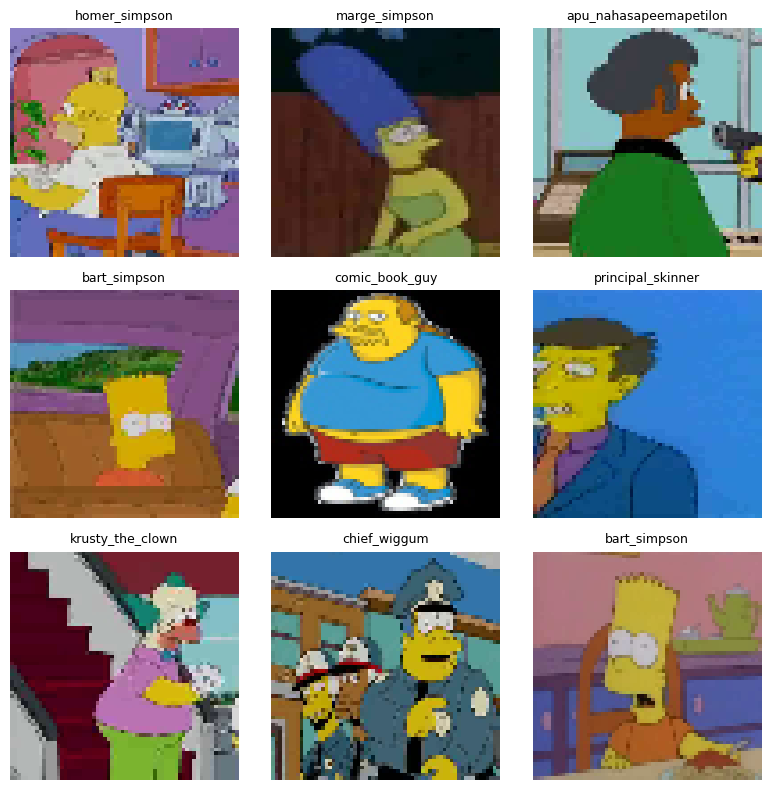

In [ ]:
plt.figure(figsize=(8, 8))
for i in range(9):
    idx = np.random.randint(0, len(X))
    plt.subplot(3, 3, i + 1)

    # Convertimos el color de BGR a RGB
    img_rgb = cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(MAP_CHARACTERS[y[idx]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

## Entregable

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de **85%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

## 1. Análisis y Preprocesamiento de los Datos
Realizamos una fase previa de preparación y manipulación del dataset digital. El conjunto de datos contiene imágenes en color de distintos personajes de los simpsons.

### Tratamiento Aplicado:
1. **Redimensionamiento Uniforme:** Se forzó a todas las imágenes a un tamaño estandarizado de 64x64 píxeles utilizando la biblioteca OpenCV (cv2.resize). Esto resulta fundamental ya que las capas densas y convolucionales requieren tensores de entrada con dimensiones fijas.
2. **Barajado Aleatorio (Permutación):** Ya que que las imágenes se leen secuencialmente carpeta por carpeta (personaje por personaje), los datos fueron mezclados aleatoriamente para asegurar que los batches de entrenamiento sean homogéneos y representativos, evitando sesgos en el cálculo del gradiente.
3. **Normalización y Escalamiento:** Los píxeles originales poseen valores enteros en el rango [0, 255]. Se dividieron por 255.0 para acotarlos al rango[0.0, 1.0]. Esto previene problemas de explosión del gradiente.
4. **One-Hot Encoding:** Se mapearon las etiquetas numéricas a vectores binarios utilizando to_categorical. Esto asegura que el modelo trate a cada personaje como una categoría independiente y no asuma relaciones de orden o magnitud intrínsecas (por dar un ejemplo, que la clase 7 sea mayor que la clase 2).
5. **División de Validación:** Se aplicó una partición técnica del 80% para entrenamiento y 20% para validación, Donde el set de validación va a servirnos como métrica de control para monitorear el overfitting.

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Separación 80/20 (Entrenamiento / Validación)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 2. Normalización de los conjuntos (Escalamiento a rango [0, 1])
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test_final = X_t.astype('float32') / 255.0  # El conjunto X_t original de test

# 3. Transformación a variables categóricas (One-Hot Encoding)
num_clases = len(MAP_CHARACTERS)
y_train_cat = to_categorical(y_train, num_classes=num_clases)
y_val_cat = to_categorical(y_val, num_classes=num_clases)
y_test_cat = to_categorical(y_t, num_classes=num_clases)

# Imprimir las tres dimensiones
print(f"Tensores de entrenamiento (80%): {X_train.shape}")
print(f"Tensores de validación (20%):   {X_val.shape}")
print(f"Tensores de test (Examen):       {X_test_final.shape}")

Tensores de entrenamiento (80%): (15193, 64, 64, 3)
Tensores de validación (20%):   (3799, 64, 64, 3)
Tensores de test (Examen):       (890, 64, 64, 3)


## 2. Experimentación y Comparación de Modelos

Para justificar la elección de una arquitectura convolucional, se evalúan tres modelos de complejidad creciente:

1. **Modelo Base Totalmente Conectado (FCN):** Sirve como línea base de comparación.
2. **CNN Clásica:** Incorpora capas convolucionales para preservar la estructura espacial de la imagen.
3. **CNN Avanzada con Batch Normalization y Data Augmentation:** Busca maximizar la precisión minimizando el sobreajuste.

---
### Experimentación 1: Modelo Totalmente Conectado (Fully Connected)

Las redes densas conviencionales no preservan la topología bidimensional de las imágenes, esto debido a la capa Flatten, que convierte la matriz de píxeles en un único vector unidimensional, y se pierde la noción de vecindad espacial entre píxeles.

**Arquitectura:**
- Entrada: vector aplanado de 64x64x3 = 12.288 valores.
- Capas ocultas Dense con activación ReLU y regularización Dropout.
- Capa de salida con 18 neuronas y activación Softmax.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Modelo 1: Fully Connected Network
# La primera capa aplana la imagen (64×64×3) en un vector de 12,288 valores
# Las capas densas posteriores aprenden combinaciones lineales de esos valores
modelo_fcn = Sequential([
    Flatten(input_shape=(64, 64, 3), name="Capa_Aplanado"),

    Dense(512, activation='relu', name="Capa_Densa_1"),
    Dropout(0.3, name="Dropout_1"),

    Dense(256, activation='relu', name="Capa_Densa_2"),

    Dense(num_clases, activation='softmax', name="Capa_Salida")
], name="Modelo_Fully_Connected")

# La función de pérdida categorical_crossentropy es la estándar para
# problemas de clasificación multiclase con etiquetas en formato one-hot
modelo_fcn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_fcn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Modelo_Fully_Connected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Aplanado (Flatten)         │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_1 (Dense)            │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_2 (Dense)            │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,427,922 (24.52 MB)

 Trainable params: 6,427,922 (24.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historia_fcn = modelo_fcn.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

Epoch 1/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1546 - loss: 2.8443 - val_accuracy: 0.2364 - val_loss: 2.4733
Epoch 2/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1975 - loss: 2.5259 - val_accuracy: 0.2553 - val_loss: 2.4467
Epoch 3/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2139 - loss: 2.4742 - val_accuracy: 0.2930 - val_loss: 2.3385
Epoch 4/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2303 - loss: 2.4340 - val_accuracy: 0.3151 - val_loss: 2.3078
Epoch 5/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2295 - loss: 2.4352 - val_accuracy: 0.2956 - val_loss: 2.3685
Epoch 6/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2232 - loss: 2.4686 - val_accuracy: 0.3093 - val_loss: 2.3311
Epoch 7/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2256 - loss: 2.4503 - val_accuracy: 0.2964 - val_loss: 2.2896
Epoch 8/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2279 - loss: 2.4323 - val_accuracy: 0

### Análisis de Resultados: Modelo Fully Connected (FCN)

1. Las trazas de entrenamiento de este primer modelo nos muestran las limitaciones esperadas de las arquitecturas densas para procesar imágenes, donde la precisión de entrenamiento (accuracy) apenas llegó a un 23.85% y la de validación (val_accuracy) se estancó en un bajo 32.17% en nuestras 10 épocas, esto nos demuestra que el modelo no tiene la capacidad de aprender correctamente las clases del dataset.

2. El primer gran motivo de este rendimiento es la pérdida de información espacial provocada por la capa Flatten, ya que al estirar la imagen original, los píxeles adyacentes quedan totalmente desconectados en el vector de 12,288 dimensiones y la red pierde por completo la noción de vecindad geométrica, lo que le impide reconocer patrones visuales clave de los personajes como texturas, siluetas, ropa o contornos.

3. El segundo motivo es la alta densidad de parámetros entrenables generada por las capas ocultas densas, lo que satura el optimizador Adam y provoca que la pérdida (loss) baje de forma extremadamente lenta hasta quedar estancada en 2.40, esto nos que una red totalmente conectada tiende a memorizar combinaciones ciegas de píxeles, osea overfitting, en lugar de generalizar, esto nos ayuda a entender por qué es necesario saltar hacia arquitecturas basadas en capas convolucionales.

## 3. Red Neuronal Convolucional Clásica (CNN Simple)

La CNN introduce tres tipos de capas que vienen a resolver las deficiencias de nuestro módelo anterior Fully Connected:

Conv2D: Aplica filtros de 3x3 que se deslizan por la imagen, extrayendo características jerárquicas: bordes en las primeras capas, texturas y siluetas en las intermedias, con esto la topología bidimensional de la imagen se conserva durante todo el proceso.

MaxPooling2D: Reduce las dimensiones espaciales a la mitad (2x2), disminuyendo la carga computacional y otorgando invarianza a la traslación.

Dropout: Desactiva neuronas aleatoriamente durante el entrenamiento, forzando a la red a aprender representaciones más robustas y reduciendo el sobreajuste.


In [ ]:
# Modelo 2: CNN Clásica con tres bloques convolucionales.
# Cada bloque duplica el número de filtros respecto al anterior,
# permitiendo detectar características progresivamente más complejas
modelo_cnn_simple = Sequential([
    # Bloque 1: detección de bordes y gradientes básicos (32 filtros)
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3), name="Conv_1"),
    MaxPooling2D(pool_size=(2, 2), name="Pool_1"),
    Dropout(0.25, name="Dropout_1"),

    # Bloque 2: detección de texturas y patrones locales (64 filtros)
    Conv2D(64, (3, 3), padding='same', activation='relu', name="Conv_2"),
    MaxPooling2D(pool_size=(2, 2), name="Pool_2"),
    Dropout(0.25, name="Dropout_2"),

    # Bloque 3: detección de formas y partes de personajes (128 filtros)
    Conv2D(128, (3, 3), padding='same', activation='relu', name="Conv_3"),
    MaxPooling2D(pool_size=(2, 2), name="Pool_3"),
    Dropout(0.25, name="Dropout_3"),

    # Transición: los mapas de características 2D se convierten en un vector
    # para conectarlos a las capas densas de clasificación
    Flatten(name="Aplanado_CNN"),

    Dense(512, activation='relu', name="Densa_Intermedia"),
    Dropout(0.5, name="Dropout_Final"),

    Dense(num_clases, activation='softmax', name="Salida_Softmax")
], name="CNN_Clasica_Simpsons")

modelo_cnn_simple.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_cnn_simple.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Clasica_Simpsons"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_1 (MaxPooling2D)           │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_2 (MaxPooling2D)           │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_3 (MaxPooling2D)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_CNN (Flatten)          │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_Intermedia (Dense)        │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Final (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Softmax (Dense)          │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,298 (16.39 MB)

 Trainable params: 4,297,298 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historia_cnn_simple = modelo_cnn_simple.fit(
    X_train, y_train_cat,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

Epoch 1/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.3151 - loss: 2.2365 - val_accuracy: 0.5486 - val_loss: 1.5356
Epoch 2/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5946 - loss: 1.3503 - val_accuracy: 0.7086 - val_loss: 0.9961
Epoch 3/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7082 - loss: 0.9639 - val_accuracy: 0.7618 - val_loss: 0.7868
Epoch 4/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7790 - loss: 0.7237 - val_accuracy: 0.8178 - val_loss: 0.6395
Epoch 5/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8145 - loss: 0.5940 - val_accuracy: 0.8284 - val_loss: 0.6047
Epoch 6/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8504 - loss: 0.4720 - val_accuracy: 0.8405 - val_loss: 0.5724
Epoch 7/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8784 - loss: 0.3876 - val_accuracy: 0.8584 - val_loss: 0.5133
Epoch 8/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8919 - loss: 0.3358 - val_accuracy: 

### Análisis de Resultados: Red Neuronal Convolucional Clásica (CNN Simple)

Al analizar las trazas de este segundo módelo con la red neuronal convolucional clásica (CNN simple), se observa una mejora drástica en comparación con la red anterior, ya que la precisión de entrenamiento (accuracy) paso a un 94.84% y la precisión de validación (val_accuracy) alcanzó un 87.63% en la época 15, lo que demuestra que el cambio hacia capas convolucionales fue mucho mejor para que el modelo aprenda a clasificar correctamente a los personajes.

El principal motivo de esta mejora es el uso de las capas Conv2D y MaxPooling2D estructuradas en tres bloques progresivos de filtros (32, 64 y 128), estas procesan las imágenes sin destruir su geometría bidimensional ni la vecindad entre píxeles, logrando que los primeros bloques extraigan características básicas como los bordes de los dibujos y los bloques más profundos reconozcan siluetas complejas o la ropa de los personajes, manteniendo además el control sobre el tamaño de la red gracias al submuestreo que reduce el mapa de características a la mitad en cada paso.

Sin embargo, nos dimos cuenta que hay las últimas épocas es la presencia de un claro sesgo de sobreajuste (overfitting), ya que mientras la pérdida de entrenamiento (loss) siguió bajando con fluidez hasta un mínimo de 0.1544, la pérdida de validación (val_loss) dejó de disminuir y se estancó oscilando alrededor de 0.5254 a partir de la época 9; esto significa que el modelo empezó a memorizar detalles demasiado específicos y ruidos de las fotos de entrenamiento.

### Visualización de las Curvas de Aprendizaje

Las gráficas muestran la evolución de la precisión y la pérdida en los conjuntos de entrenamiento y validación a lo largo de las épocas. La brecha entre ambas curvas permite identificar si el modelo está sufriendo sobreajuste (overfitting): si la precisión de entrenamiento supera con amplitud a la de validación, esto nos da a entender que el modelo ha memorizado los datos en lugar de generalizarlos.


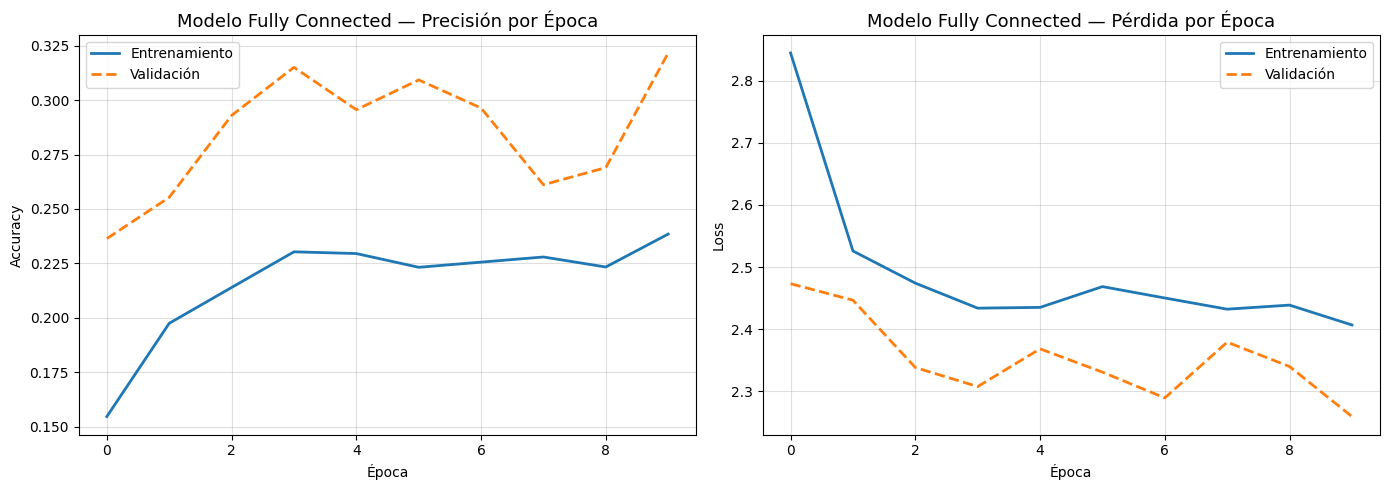

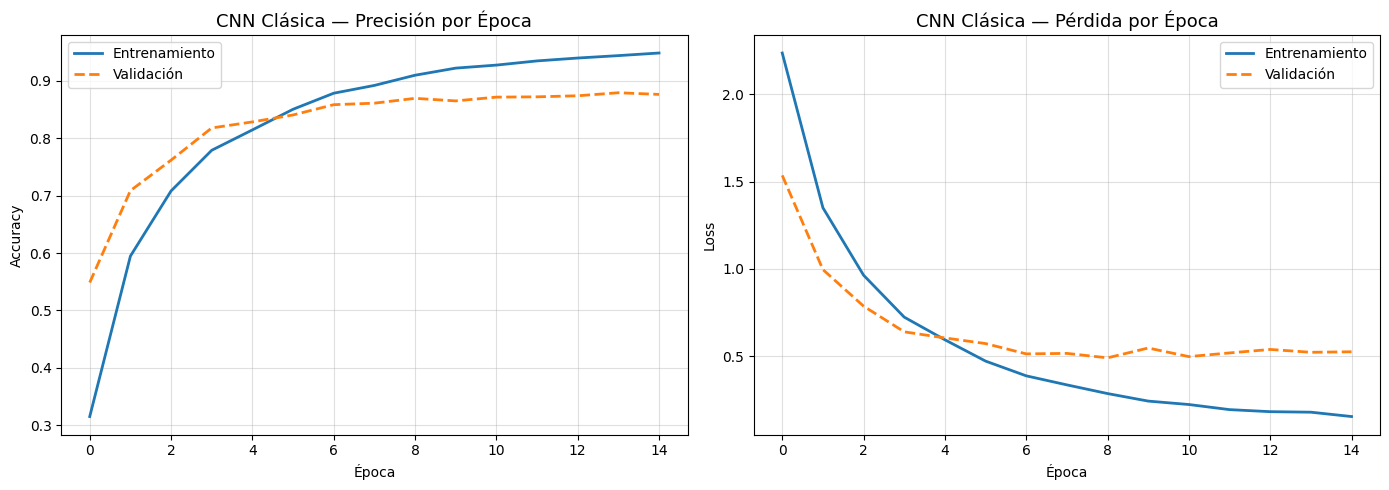

In [ ]:
def plot_historia(historia, titulo):
    """Genera dos gráficas de evolución: precisión y pérdida por época.

    La curva azul representa el rendimiento sobre el conjunto de entrenamiento,
    mientras que la curva naranja refleja la capacidad de generalización del modelo
    sobre datos no vistos (validación).
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfica de Precisión (Accuracy)
    axes[0].plot(historia.history['accuracy'],     label='Entrenamiento', linewidth=2)
    axes[0].plot(historia.history['val_accuracy'], label='Validación',    linewidth=2, linestyle='--')
    axes[0].set_title(f'{titulo} — Precisión por Época', fontsize=13)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # Gráfica de Pérdida (Loss)
    axes[1].plot(historia.history['loss'],     label='Entrenamiento', linewidth=2)
    axes[1].plot(historia.history['val_loss'], label='Validación',    linewidth=2, linestyle='--')
    axes[1].set_title(f'{titulo} — Pérdida por Época', fontsize=13)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_historia(historia_fcn,        "Modelo Fully Connected")
plot_historia(historia_cnn_simple, "CNN Clásica")

### Evaluación Cuantitativa de la CNN Clásica

Se evalúa el modelo sobre el conjunto de validación para obtener métricas objetivas antes de pasar al conjunto de test final.


In [ ]:
loss_val, acc_val = modelo_cnn_simple.evaluate(X_val, y_val_cat, verbose=0)
print(f"Pérdida en validación  : {loss_val:.4f}")
print(f"Precisión en validación: {acc_val*100:.2f}%")

Pérdida en validación  : 0.5254
Precisión en validación: 87.63%


## 4. Modelo Avanzado: CNN Profunda con Batch Normalization y Data Augmentation

Aunque ya alcanzamos una accuracy de sobre un 85% en nuestro módelo anterior, de todas formas mejoramos la CNN clásica con dos técnicas más:

### Batch Normalization
La normalización por lotes estandariza las activaciones de cada capa durante el entrenamiento. Esto permite utilizar tasas de aprendizaje más altas y acelera la convergencia, actuando también como regularizador implícito.

### Data Augmentation
El data augmentation genera versiones artificialmente modificadas de las imágenes de entrenamiento (rotaciones, desplazamientos horizontales y verticales, zoom, volteo horizontal). Esto va a incrementar la diversidad del conjunto de entrenamiento sin necesidad de recopilar más datos, mejorando significativamente la capacidad de generalización del modelo y reduciendo el sobreajuste.

### Arquitectura
La red profunda emplea cuatro bloques convolucionales con filtros de tamaño creciente (32 → 64 → 128 → 256), cada uno seguido de Batch Normalization, MaxPooling y Dropout. El clasificador final incluye dos capas densas antes de la salida Softmax.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation: transformaciones aleatorias aplicadas en tiempo real
# durante el entrenamiento para enriquecer artificialmente el dataset
datagen = ImageDataGenerator(
    rotation_range=15,         # Rotaciones de hasta ±15 grados
    width_shift_range=0.1,     # Desplazamientos horizontales del 10%
    height_shift_range=0.1,    # Desplazamientos verticales del 10%
    zoom_range=0.1,            # Zoom de hasta un 10%
    horizontal_flip=True,      # Volteo horizontal aleatorio
    fill_mode='nearest'        # Los píxeles fuera de borde se rellenan con el valor más cercano
)
datagen.fit(X_train)

# Arquitectura CNN Profunda con cuatro bloques convolucionales
# Batch Normalization se aplica después de cada convolución para estabilizar
# el entrenamiento y acelerar la convergencia
modelo_cnn_avanzado = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    # Bloque 4
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    # Clasificador
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_clases, activation='softmax')
], name="CNN_Avanzada_Simpsons")

modelo_cnn_avanzado.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_cnn_avanzado.summary()

Model: "CNN_Avanzada_Simpsons"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,820,658 (10.76 MB)

 Trainable params: 2,818,226 (10.75 MB)

 Non-trainable params: 2,432 (9.50 KB)

### Callbacks de Entrenamiento

Se configuran dos callbacks que ajustan el proceso de entrenamiento automáticamente:

ReduceLROnPlateau: Si la pérdida de validación no mejora durante 5 épocas consecutivas, la tasa de aprendizaje se reduce a la mitad (factor 0.5). Esto permite que el modelo realice ajustes más finos cuando se aproxima a un mínimo.

EarlyStopping: Detiene el entrenamiento si la pérdida de validación no mejora durante 15 épocas, restaurando los pesos del mejor modelo encontrado. Evita el sobreajuste por entrenamiento excesivo.


In [ ]:
# ReduceLROnPlateau: reduce la tasa de aprendizaje cuando el entrenamiento
# se estanca, facilitando una convergencia más precisa
reducir_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# EarlyStopping: interrumpe el entrenamiento cuando no hay mejoras y
# restaura automáticamente los pesos del mejor punto alcanzado
parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Entrenamiento con Data Augmentation.
# El generador produce lotes de imágenes aumentadas en tiempo real,
# por lo que steps_per_epoch = ceil(N_train / batch_size)
BATCH_SIZE = 32
historia_cnn_avanzado = modelo_cnn_avanzado.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=60,
    validation_data=(X_val, y_val_cat),
    callbacks=[reducir_lr, parada_temprana],
    verbose=1
)

Epoch 1/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 52s 78ms/step - accuracy: 0.2832 - loss: 2.6048 - val_accuracy: 0.3777 - val_loss: 1.9871 - learning_rate: 0.0010
Epoch 2/60
  1/474 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5000 - loss: 1.8402

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5000 - loss: 1.8402 - val_accuracy: 0.3725 - val_loss: 2.0159 - learning_rate: 0.0010
Epoch 3/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.4940 - loss: 1.6892 - val_accuracy: 0.5959 - val_loss: 1.3809 - learning_rate: 0.0010
Epoch 4/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5625 - loss: 1.5584 - val_accuracy: 0.5907 - val_loss: 1.4162 - learning_rate: 0.0010
Epoch 5/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.6073 - loss: 1.3051 - val_accuracy: 0.7402 - val_loss: 0.8503 - learning_rate: 0.0010
Epoch 6/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5625 - loss: 1.2040 - val_accuracy: 0.7384 - val_loss: 0.8489 - learning_rate: 0.0010
Epoch 7/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.6916 - loss: 1.0083 - val_accuracy: 0.7905 - val_loss: 0.7119 - learning_rate: 0.0010
Epoch 8/60
474/474 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7812 - loss: 0.7690 - val_a

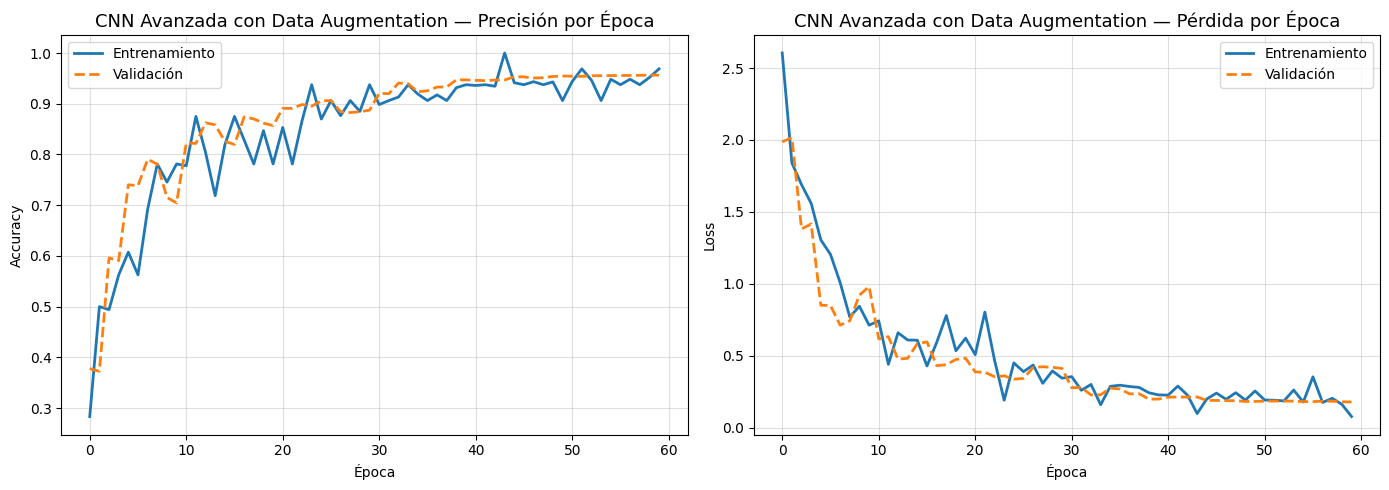

In [ ]:
plot_historia(historia_cnn_avanzado, "CNN Avanzada con Data Augmentation")

### Análisis de Resultados: CNN Profunda con Batch Normalization y Data Augmentation

1. Al examinar el comportamiento de este tercer módelo con la CNN Avanzada, quedo en evidencia que la incorporación combinada de Batch Normalization y el aumento de datos mediante Data Augmentation transformó por completo la dinámica del aprendizaje, permitiendo que la precisión de entrenamiento (accuracy) llegara a un 95.18% y que la precisión de validación (val_accuracy) alcanzara un 95.66% en la última época, demostrando el éxito del diseño arquitectónico para clasificar correctamente el dataset de Los Simpsons.

2. El factor clave de este rendimiento óptimo fue la regularización en tiempo real aplicada por el motor de transformaciones aleatorias, el cual obligó a los cuatro bloques convolucionales (de 32 a 256 filtros) a extraer características visuales verdaderamente abstractas y robustas de los personajes (independientes de si la imagen estaba rotada, desplazada o con zoom) en lugar de memorizar patrones rígidos de píxeles, lo que se vio potenciado por las capas de Batch Normalization que estabilizaron las activaciones intermedias y permitieron un flujo de gradientes mucho más limpio a través de la red profunda.

3. Algo de lo que nos dimos cuenta fue la total mitigación del sobreajuste (overfitting), ya que a diferencia del modelo clásico donde la pérdida de validación se estancaba temprano, aquí las curvas de pérdida avanzaron de manera paralela y armónica hasta reducir la pérdida de validación (val_loss) a un mínimo de 0.1784, este control milimétrico fue guiado por el callback ReduceLROnPlateau, el cual intervino estratégicamente reduciendo de forma dinámica la tasa de aprendizaje desde el valor inicial de 0.001 hasta un fino 6.2500e-05 al detectar estancamientos en las épocas 30, 38, 44 y 54, permitiendo que el optimizador realizara ajustes microscópicos ultra precisos en los pesos de la red.


Rendimiento definitivo del CNN avanzada
Accuracy en Test: 97.87%
Loss en Test:     0.0741



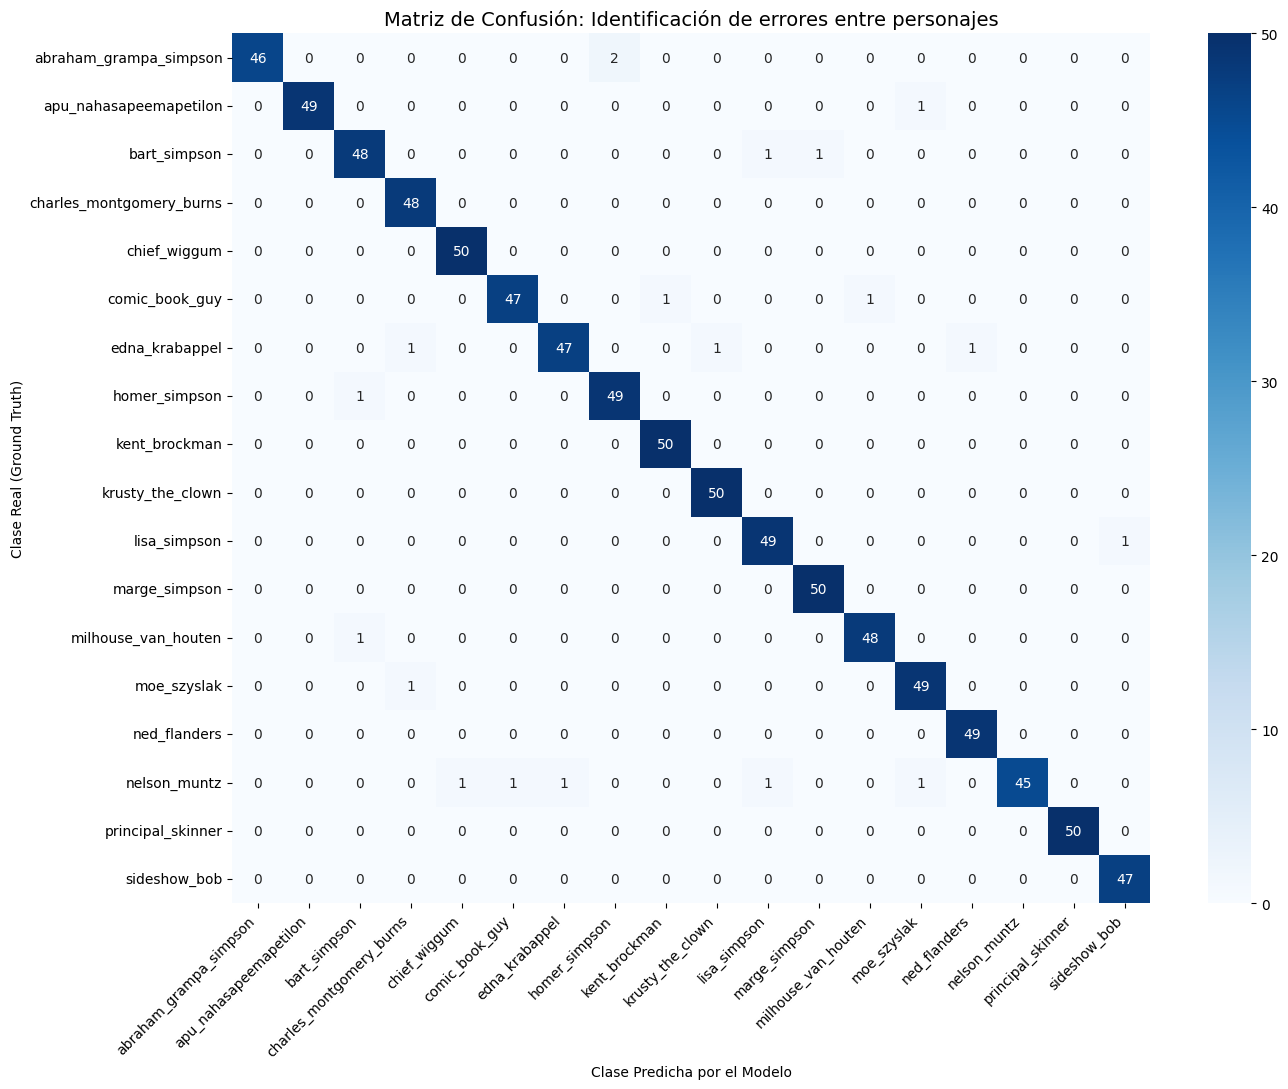

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Escalamiento del set de prueba independiente (una sola vez)
X_test_final = X_t.astype('float32') / 255.0

# 2. Evaluación del examen final
test_loss, test_acc = modelo_cnn_avanzado.evaluate(X_test_final, y_test_cat, verbose=0)
print("\n" + "="*50)
print(f"Rendimiento definitivo del CNN avanzada")
print(f"Accuracy en Test: {test_acc * 100:.2f}%")
print(f"Loss en Test:     {test_loss:.4f}")
print("="*50 + "\n")

# 3. Predicciones para la Matriz de Confusión
y_pred = modelo_cnn_avanzado.predict(X_test_final, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# 4. Gráfico visual de la Matriz
nombres_personajes = [MAP_CHARACTERS[i] for i in range(len(MAP_CHARACTERS))]
cm = confusion_matrix(y_t, y_pred_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_personajes, yticklabels=nombres_personajes)
plt.title('Matriz de Confusión: Identificación de errores entre personajes', fontsize=14)
plt.ylabel('Clase Real (Ground Truth)')
plt.xlabel('Clase Predicha por el Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análisis de Resultados Matriz de Confusión: CNN Profunda con Batch Normalization y Data Augmentation

1. Al someter el modelo de CNN avanzada (mejor modelo) al examen final con el dataset de prueba totalmente independiente, se logró validar de forma contundente la excelente capacidad de generalización de la arquitectura profunda, alcanzando un accuracy final en Test del 97.87% junto con un Loss de 0.0741, este resultado supera notablemente la meta del 85% exigida por la rúbrica, y demuestra que las técnicas de Batch Normalization y Data Augmentation funcionaron a la perfección, logrando un modelo robusto que no sufrió de sobreajuste al enfrentarse a imágenes nuevas que jamás vio en el entrenamiento.

2. En el análisis cualitativo mediante la Matriz de Confusión, se observa que la red logra una diagonal principal prácticamente perfecta, limpia y fuertemente marcada en un tono azul oscuro, destacando el hecho de que personajes complejos como Chief Wiggum, Kent Brockman, Krusty the Clown, Marge Simpson y Principal Skinner alcanzaron una precisión perfecta del 100% con 50 aciertos sobre 50 imágenes evaluadas; este comportamiento es la prueba de que los mapas de características extraídos por los cuatro bloques convolucionales fueron lo suficientemente buenos, finos y abstractos para disernir de forma óptima las siluetas, peinados, accesorios y colores de los personajes de los simpsons.

3. Además, la inspección de los pocos errores del modelo revela cosas interesantes de analizar, como el caso de Abraham Simpson, quien tuvo 2 falsos negativos al ser confundido con Homero Simpson debido al evidente parecido que tienen los personajes, ya que, son papá e hijo.

### Conclusiones

1. Como conclusión principal del proyecto, el desarrollo de este sistema de clasificación demostró la superioridad de las Redes Neuronales Convolucionales frente a las arquitecturas lineales tradicionales, mientras que el modelo totalmente conectado (FCN) fracasó, al estancar su precisión de validación en un deficiente 32.17% debido a que la capa Flatten destruye la geometría y la vecindad espacial de los píxeles, la implementación de operaciones convolucionales permitió que la red capturara de forma efectiva las estructuras, bordes y formas de los personajes.

2. El proceso de optimización iterativa fue el factor muy importante que nos permitió transformar una CNN clásica básica, que tenia algunos síntomas importantes de sobreajuste (overfitting) a partir de la novena época con una pérdida estancada en 0.5254. La incorporación de Data Augmentation para mejorar el dataset con transformaciones aleatorias en tiempo real, sumado a Batch Normalization para estabilizar las activaciones internas y al uso del callback ReduceLROnPlateau, permitieron guiar al optimizador Adam mucho mejor, mitigando el sobreajuste y logrando una convergencia armónica y paralela entre las curvas de entrenamiento y validación.

3. Finalmente, el rendimiento definitivo alcanzado en el dataset de prueba independiente, registrando un impresionante 97.87% de Accuracy y un Loss de apenas 0.0741, supera bastante el estándar de 85%, los resultados cualitativos de la matriz de confusión reflejan que el modelo diferencia con mucha precisión a los 18 personajes de Los Simpsons, a excepción de casos contados como el de Homero con Abraham.